In [8]:
import os
if not os.path.exists("./Plots"):
    os.makedirs("./Plots")

# Trick to plot with tex
os.environ["LD_LIBRARY_PATH"] = ""
os.environ["CONDA_PREFIX"] = "/home/guerrini/.conda/envs/sp_validation_3.11"

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import seaborn as sns
from getdist import plots, loadMCSamples, MCSamples

from shear_psf_leakage.rho_tau_stat import RhoStat, TauStat, PSFErrorFit

# Use paper style and seaborn with husl palette
plt.style.use(
    "/home/guerrini/matplotlib_config/paper.mplstyle"
)
# Set default palette - will be updated per plot as needed
sns.set_palette("husl")
%matplotlib inline

g = plots.get_subplot_plotter(width_inch=30)
g.settings.axes_fontsize=30
g.settings.axes_labelsize=30
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 25

In [15]:
data_path = "/home/guerrini/sp_validation/cosmo_inference/data/"

path_cosmo_val = "/home/guerrini/sp_validation/cosmo_val/output/"

roots_cosmo_val = [
    "SP_v1.4.6",
    "SP_v1.4.6_leak_corr"
]

roots = [
    "SP_v1.4.6_no_leak_corr_A_masked",
    "SP_v1.4.6_leak_corr_A_masked"
]

labels = [
    "SP_v1.4.6_A",
    "SP_v1.4.6_A leakage corrected"
]

In [16]:
data_vectors = []

for root in roots:
    data_vectors.append(
        fits.open(data_path + root +f"/cosmosis_{root}.fits")
    )

In [17]:
def cov_to_corr(cov):
    """Convert a covariance matrix to a correlation matrix."""
    d = np.sqrt(np.diag(cov))
    corr = cov / np.outer(d, d)
    corr[cov == 0] = 0
    return corr

Covariance matrix for SP_v1.4.6_A:


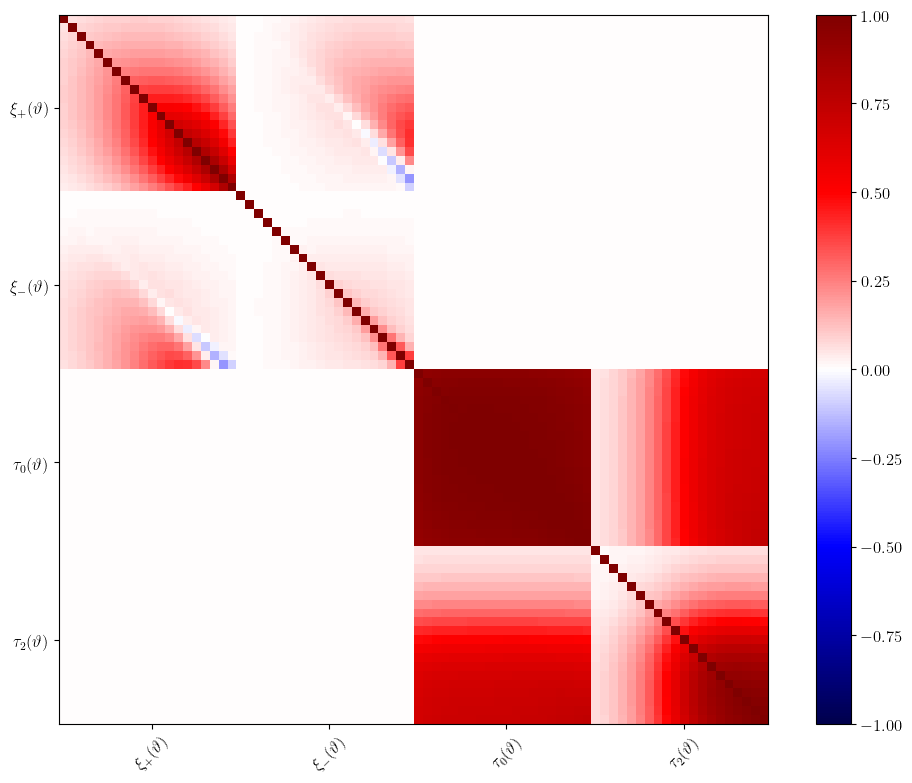



Covariance matrix for SP_v1.4.6_A leakage corrected:


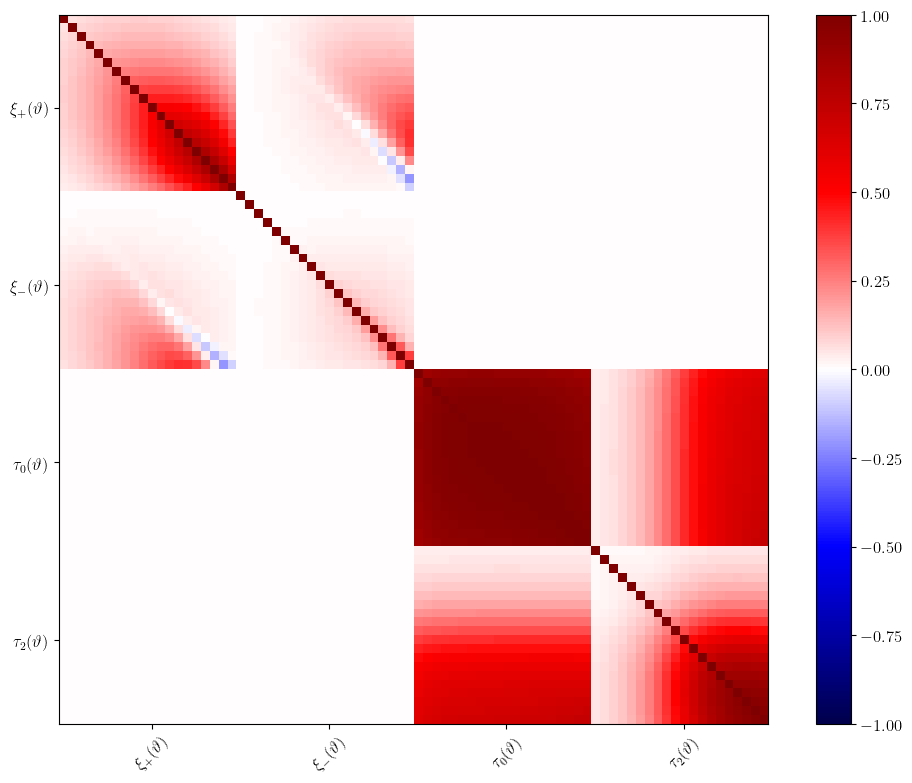

In [18]:
#Print the covariance matrix for each root
for i, root in enumerate(roots):
    print(f"Covariance matrix for {labels[i]}:")
    cov = data_vectors[i]["COVMAT"].data

    n_bins = cov.shape[0] // 4

    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(cov_to_corr(cov), vmin=-1, vmax=1, cmap="seismic")
    ax.set_aspect('equal')
    ax.set_yticks(np.array([10, 30, 50, 70]))
    ax.set_yticklabels([r"$\xi_+(\vartheta)$", r"$\xi_-(\vartheta)$", r"$\tau_0(\vartheta)$", r"$\tau_2(\vartheta)$"])
    ax.set_xticks(np.array([10, 30, 50, 70]))
    ax.set_xticklabels([r"$\xi_+(\vartheta)$", r"$\xi_-(\vartheta)$", r"$\tau_0(\vartheta)$", r"$\tau_2(\vartheta)$"], rotation=45)
    fig.colorbar(im, ax=ax)

    plt.savefig(f"./Plots/cov_matrix_{root}.png", bbox_inches='tight', dpi=300)
    plt.show()
    print("\n")

In [19]:
#Create dummy rho and tau stat handler.

#Inference of the xi_sys parameters
sep_units = 'arcmin'
coord_units = 'degrees'
theta_min = 1.0
theta_max = 250
nbins = 20


TreeCorrConfig_xi = {
    'ra_units': coord_units,
    'dec_units': coord_units,
    'min_sep': theta_min,
    'max_sep': theta_max,
    'sep_units': sep_units,
    'nbins': nbins,
    'var_method':'jackknife',
}

rho_stats_handler = RhoStat(
    output='.',
    treecorr_config=TreeCorrConfig_xi,
    verbose=True
)

tau_stats_handler = TauStat(
    catalogs=rho_stats_handler.catalogs,
    output='.',
    treecorr_config=TreeCorrConfig_xi,
    verbose=True
    )

Class created. Don't forget to load your rho and tau statistics and define your prior and your likelihood.
Sampling PSF parameters for  SP_v1.4.6_A


  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:22<00:00, 441.50it/s]


Number of samples: 10000

Parameters constraints
----------------------
Parameter: $\alpha$=0.0222^+0.0026_0.0026
Parameter: $\beta$=0.7689^+0.1086_0.1177
Chi square: 72.57699256394396
Removed no burn in
Sampling PSF parameters for  SP_v1.4.6_A leakage corrected


100%|██████████| 10000/10000 [00:22<00:00, 444.48it/s]


Number of samples: 10000

Parameters constraints
----------------------
Parameter: $\alpha$=0.0050^+0.0021_0.0021
Parameter: $\beta$=0.8052^+0.1099_0.1126
Chi square: 70.17441453563988
Removed no burn in


/tmp/ipykernel_1331751/3037039758.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f"./Plots/psf_leakage_params.png", bbox_inches='tight', dpi=300)
/tmp/ipykernel_1331751/3037039758.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f"./Plots/psf_leakage_params.png", bbox_inches='tight', dpi=300)
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


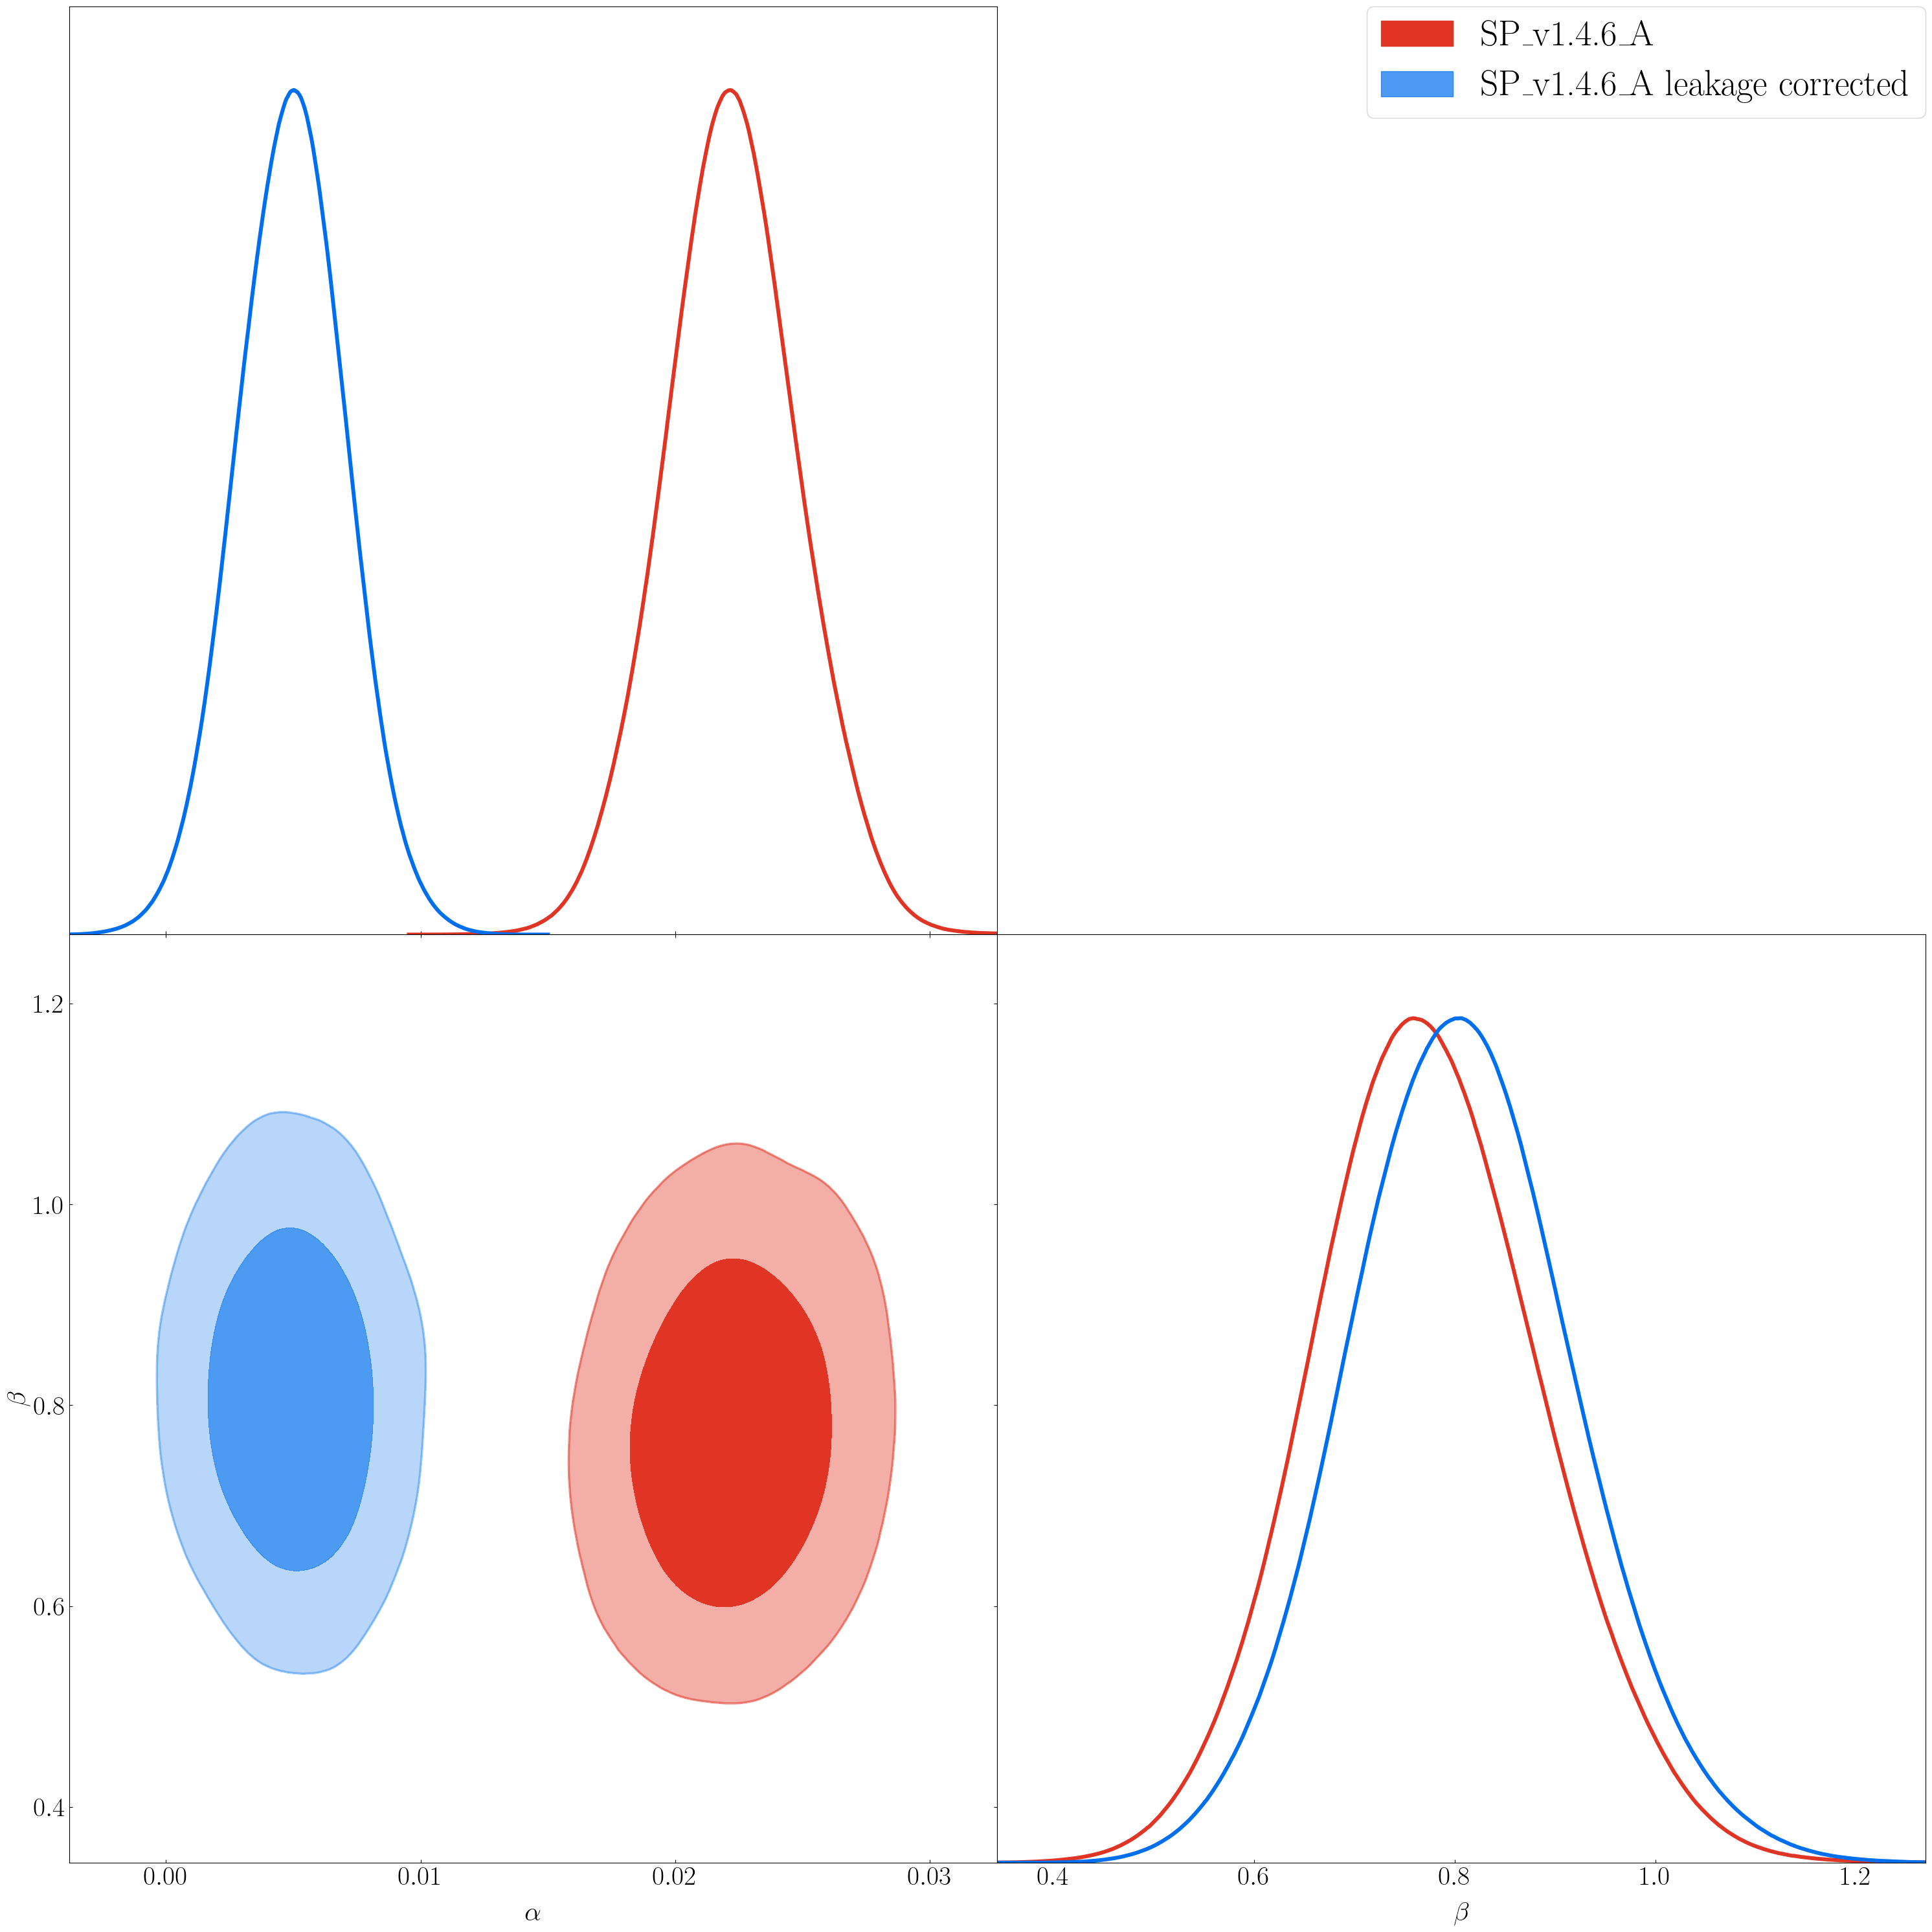

In [29]:
#Create a PSFErrorFit instance
psf_fitter = PSFErrorFit(rho_stats_handler, tau_stats_handler, path_cosmo_val+'rho_tau_stats/', use_eta=False)

def load_matrix_and_cut(root, root_cosmo_val, type='rho'):
    if type=='rho':
        cov = np.load(f"{root}/cov_rho_{root_cosmo_val}.npy")
        nbins = cov.shape[0] // 6
        cov = cov[:nbins*3, :nbins*3]
        np.save(f"{root}/cov_rho_{root_cosmo_val}_cut.npy", cov)
    elif type=='tau':
        cov = np.load(f"{root}/cov_tau_{root_cosmo_val}_th.npy")
        nbins = cov.shape[0] // 3
        cov = cov[:nbins*2, :nbins*2]
        np.save(f"{root}/cov_tau_{root_cosmo_val}_th_cut.npy", cov)
    else:
        raise ValueError("type must be 'rho' or 'tau'")

g  = plots.get_subplot_plotter(width_inch=30)

g.settings.axes_fontsize=30
g.settings.axes_labelsize=30
g.settings.alpha_filled_add = 0.7
g.settings.legend_fontsize = 40

chains = []

#Load rho-, tau-statistics, and cov_tau from the data_vector
for i, root_cosmo_val in enumerate(roots_cosmo_val):
    print("Sampling PSF parameters for ", labels[i])
    path_rho = f"rho_stats_{root_cosmo_val}.fits"
    path_tau = f"tau_stats_{root_cosmo_val}.fits"
    path_cov_rho = f"cov_rho_{root_cosmo_val}.npy"
    path_cov_tau = f"cov_tau_{root_cosmo_val}_th.npy"

    load_matrix_and_cut(path_cosmo_val+'/rho_tau_stats/', root_cosmo_val, type='rho')
    load_matrix_and_cut(path_cosmo_val+'/rho_tau_stats/', root_cosmo_val, type='tau')
    path_cov_rho = f"cov_rho_{root_cosmo_val}_cut.npy"
    path_cov_tau = f"cov_tau_{root_cosmo_val}_th_cut.npy"

    psf_fitter.load_rho_stat(path_rho)
    psf_fitter.load_tau_stat(path_tau)
    psf_fitter.load_covariance(path_cov_rho, cov_type='rho')
    psf_fitter.load_covariance(path_cov_tau, cov_type='tau')
    samples_lq, _, _ = psf_fitter.get_least_squares_params_samples(npatch=None, apply_debias=False)

    samples_gd = MCSamples(samples=samples_lq, names=[r"\alpha", r"\beta"], labels=[r"\alpha", r"\beta"])

    chains.append(samples_gd)

g.triangle_plot(chains,
                filled=True,
                legend_labels=labels,
                legend_loc='upper right'
)

plt.savefig(f"./Plots/psf_leakage_params.png", bbox_inches='tight', dpi=300)
plt.show()